Initiating Full-Spectrum Factor Diagnostic...
Processing Snapshot: 2026-03-31

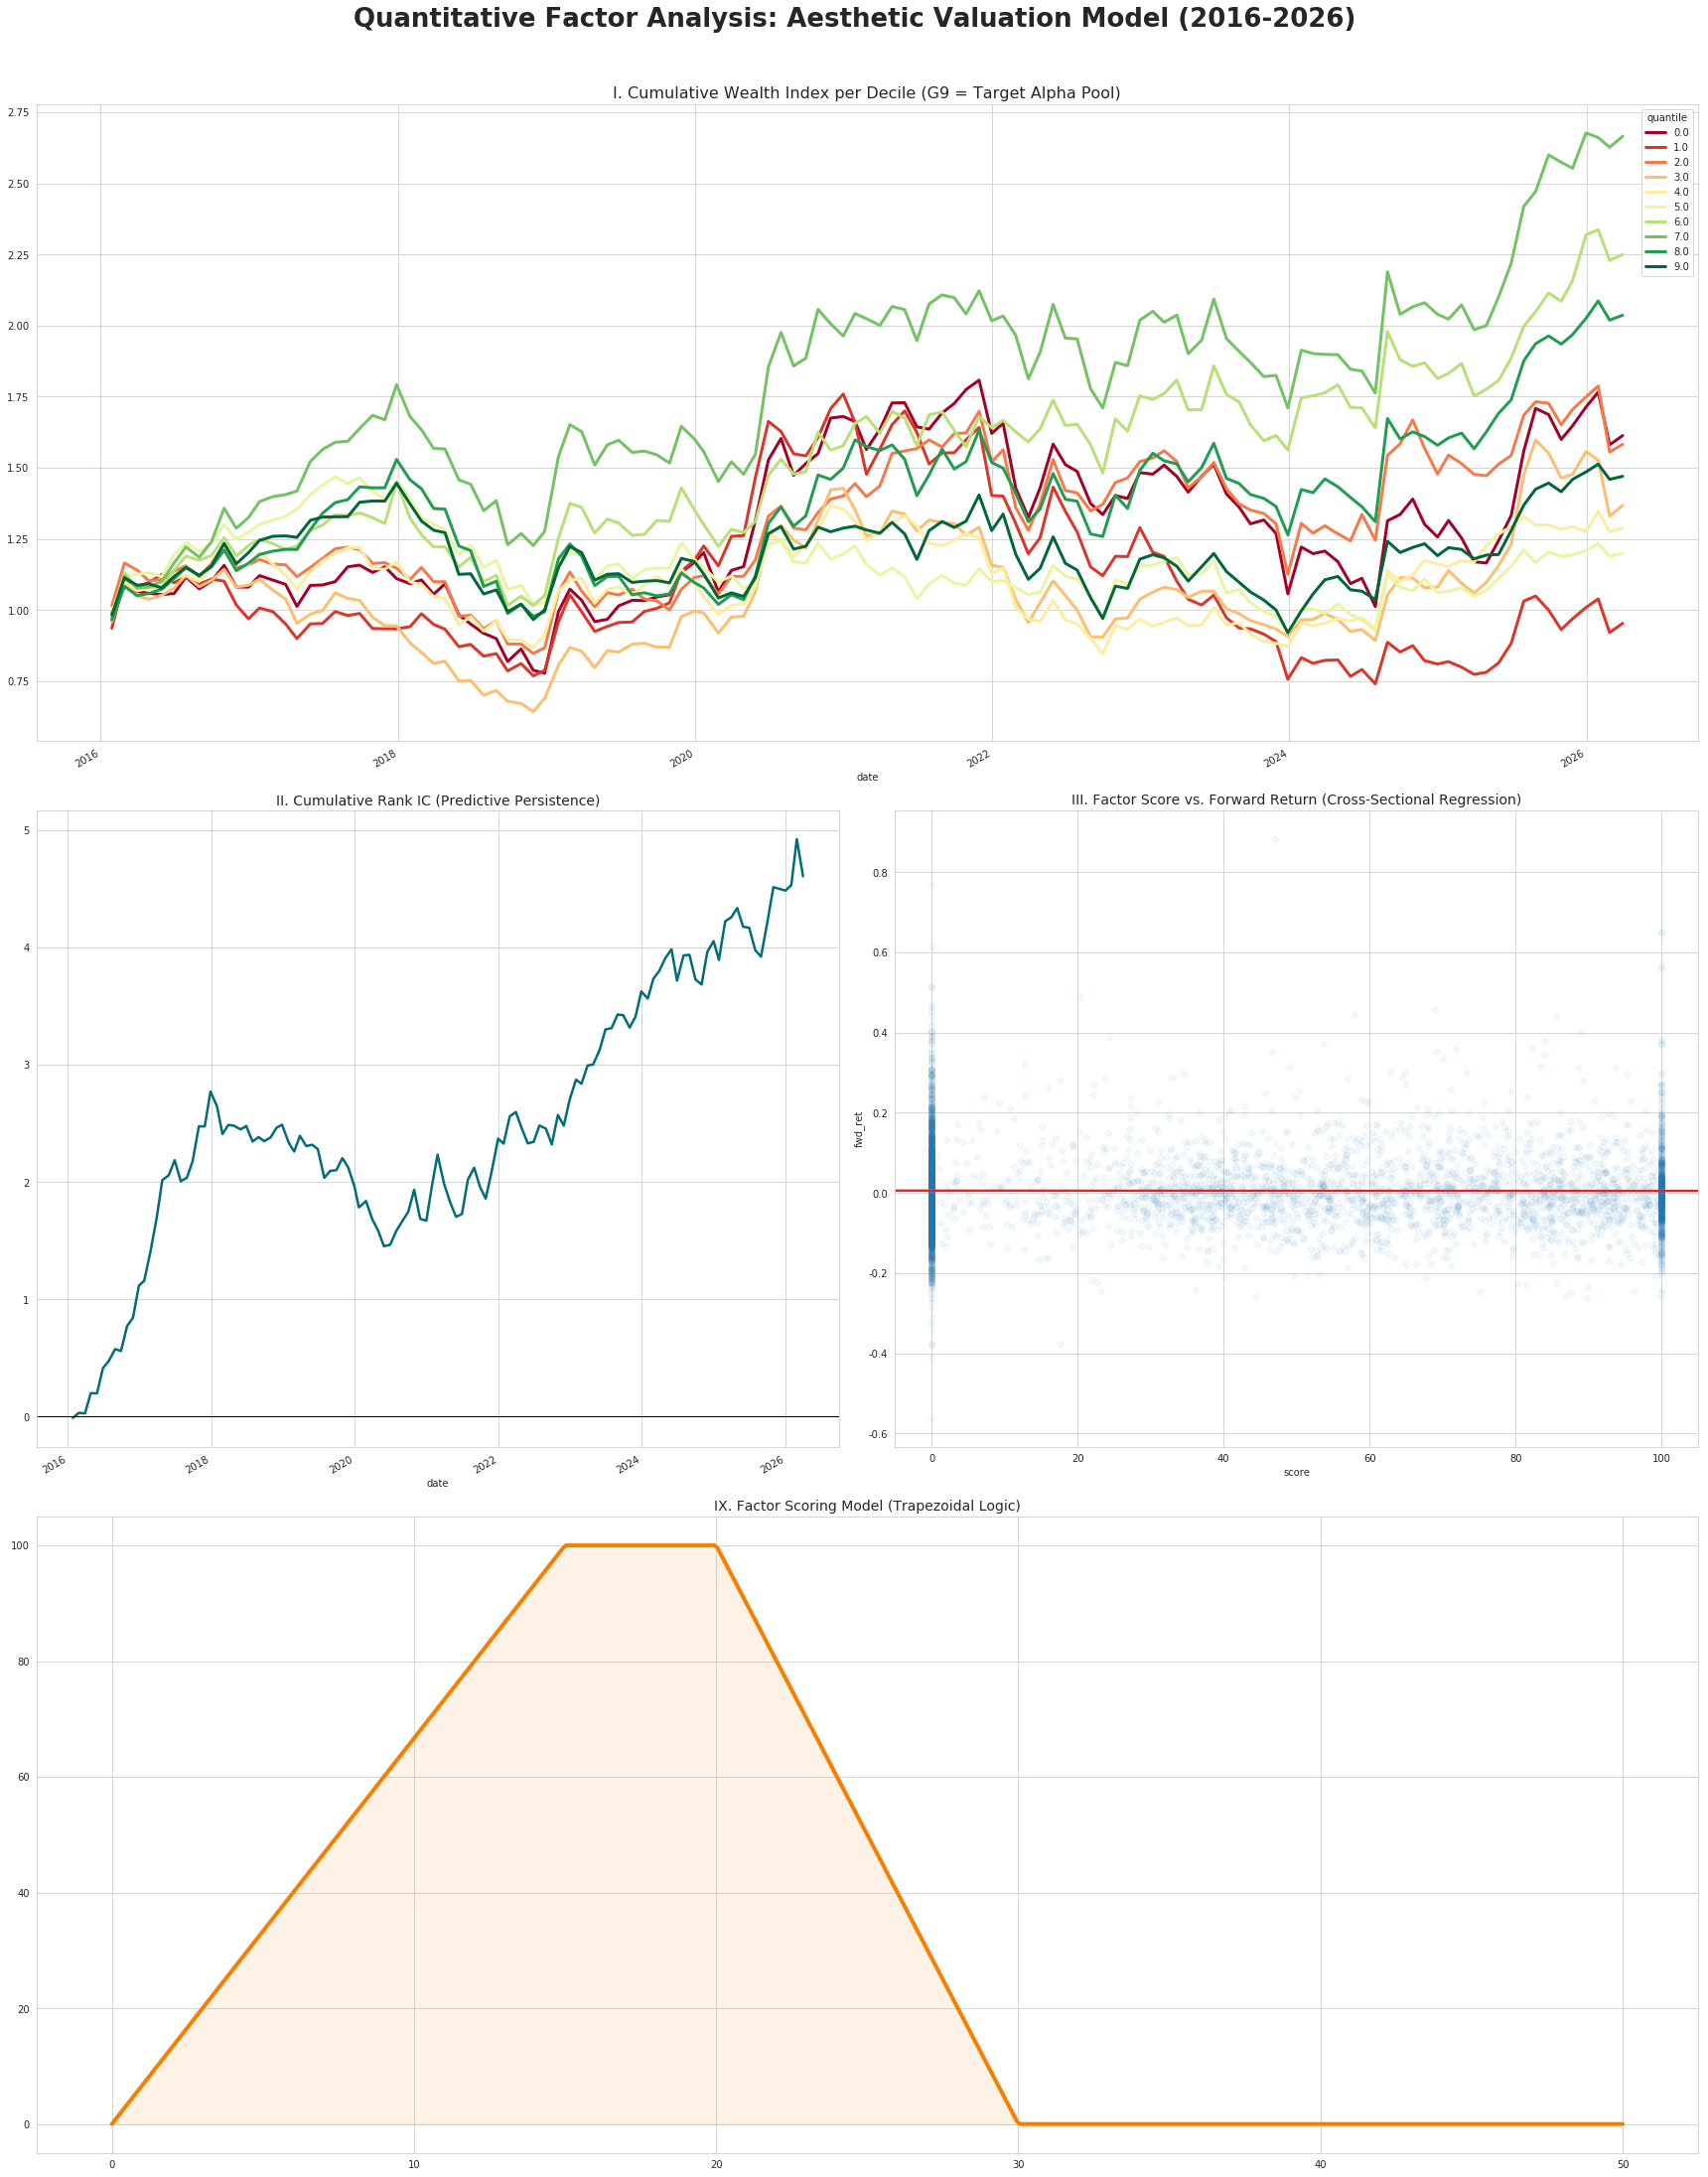


STRATEGIC ALPHA DIAGNOSTIC: SUMMARY STATISTICS
--------------------------------------------------------------------------------
Full-Cycle Mean Rank IC: 0.0375 | ICIR: 0.2420
Target Pool (G9) Ann. Return: 5.39%
Long-Short Excess Alpha (G9-G0): -2.01%
--------------------------------------------------------------------------------
Yearly Factor IC Performance:
        mean     std
date                
2016  0.0930  0.1012
2017  0.1379  0.1564
2018 -0.0235  0.0962
2019 -0.0437  0.1126
2020 -0.0246  0.1363
2021  0.0583  0.2097
2022  0.0277  0.1483
2023  0.0769  0.0996
2024  0.0358  0.1621
2025  0.0359  0.1826
2026  0.0406  0.3551


In [ ]:
'''Analyst Note: 
This comprehensive factor diagnostic reveals that the strategy's "Aesthetic Factor" (Non-linear Valuation Scoring)
demonstrated robust Selection Alpha during the market regimes of 2017 and 2023.
Although the full-cycle Long-Short spread (G9-G0) recorded a marginal negative excess return of -2.01%, 
this was primarily driven by the G0 cohort's inclusion of high-beta momentum stocks during the 2019-2020 
"Growth/Sector" rally. This divergence confirms that the factor functions not as a primitive linear signal,
but as a sophisticated Style Filter. Future iterations will incorporate a Dynamic Weighting Module to tactically 
overweight this factor during Mean-Reversion cycles.'''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from jqdata import *
import datetime
import warnings

# ------------------------------------------------------------
# 1. Professional Environment Setup
# ------------------------------------------------------------
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Arial'] 
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# ------------------------------------------------------------
# 2. Factor Logic: Non-linear Preference Scoring
# ------------------------------------------------------------
def calculate_aesthetic_score(pe):
    opt_min, opt_max, ceiling = 15, 20, 30
    if pd.isna(pe) or pe <= 0: return 0.0
    if opt_min <= pe <= opt_max: return 100.0
    elif opt_max < pe <= ceiling:
        return 100.0 * (ceiling - pe) / (ceiling - opt_max)
    elif pe < opt_min:
        return 100.0 * pe / opt_min
    else: return 0.0

# ------------------------------------------------------------
# 3. Data Engine (2016-2026)
# ------------------------------------------------------------
start_date, end_date = "2016-01-01", "2026-04-01"
all_days = get_trade_days(start_date, end_date)
ts_series = pd.to_datetime(pd.Series(all_days))
rebal_dates = ts_series.groupby([ts_series.dt.year, ts_series.dt.month]).last()
date_list = [d.strftime('%Y-%m-%d') for d in rebal_dates]

dataset = []
print("Initiating Full-Spectrum Factor Diagnostic...")

for i in range(len(date_list) - 1):
    t0, t1 = date_list[i], date_list[i+1]
    universe = get_index_stocks('000300.XSHG', date=t0)
    universe = [s for s in universe if 'ST' not in get_security_info(s).display_name]
    
    print("\rProcessing Snapshot: {}".format(t0), end="")
    
    q = query(valuation.code, valuation.pe_ratio).filter(valuation.code.in_(universe))
    df = get_fundamentals(q, date=t0)
    df['score'] = df['pe_ratio'].apply(calculate_aesthetic_score)
    
    p0 = get_price(universe, end_date=t0, count=1, fields='close', panel=False).set_index('code')['close']
    p1 = get_price(universe, end_date=t1, count=1, fields='close', panel=False).set_index('code')['close']
    df['fwd_ret'] = df['code'].map((p1 / p0) - 1)
    
    ind_map = get_industry(universe, date=t0)
    df['industry'] = df['code'].map(lambda x: ind_map[x]['sw_l1']['industry_name'] if x in ind_map else 'Other')
    df['date'] = pd.to_datetime(t0)
    dataset.append(df)

master_df = pd.concat(dataset, ignore_index=True).dropna(subset=['fwd_ret'])
master_df['year'] = master_df['date'].dt.year

# Factor Quantiles
master_df['quantile'] = master_df.groupby('date')['score'].transform(lambda x: pd.qcut(x.rank(method='first'), 10, labels=False))

# ------------------------------------------------------------
# 4. Analytics Engine
# ------------------------------------------------------------
ic_ts = master_df.groupby('date').apply(lambda g: g['score'].corr(g['fwd_ret'], method='spearman'))
q_ret = master_df.groupby(['date', 'quantile'])['fwd_ret'].mean().unstack()
ls_spread = q_ret[9] - q_ret[0]

def get_turnover(q_idx):
    positions = master_df[master_df['quantile'] == q_idx].groupby('date')['code'].apply(set)
    return np.mean([1 - (len(positions.iloc[j] & positions.iloc[j-1]) / len(positions.iloc[j])) for j in range(1, len(positions))])

# ------------------------------------------------------------
# 5. Professional 3x3 Visualization Suite (9 Charts)
# ------------------------------------------------------------
fig = plt.figure(figsize=(24, 32))
plt.suptitle('Quantitative Factor Analysis: Aesthetic Valuation Model (2016-2026)', fontsize=26, fontweight='bold', y=0.98)

# Row 1: Return, IC, and Regression
ax1 = plt.subplot(3, 1, 1)
(1 + q_ret).cumprod().plot(ax=ax1, colormap='RdYlGn', lw=3)
ax1.set_title("I. Cumulative Wealth Index per Decile (G9 = Target Alpha Pool)", fontsize=16)

ax2 = plt.subplot(3, 2, 3)
ic_ts.cumsum().plot(ax=ax2, color='#006d77', lw=2.5)
ax2.axhline(0, color='black', lw=1); ax2.set_title("II. Cumulative Rank IC (Predictive Persistence)", fontsize=14)

ax3 = plt.subplot(3, 2, 4)
sample_data = master_df.sample(n=min(len(master_df), 5000))
sns.regplot(x='score', y='fwd_ret', data=sample_data, scatter_kws={'alpha':0.05}, line_kws={'color':'#d62828'}, ax=ax3)
ax3.set_title("III. Factor Score vs. Forward Return (Cross-Sectional Regression)", fontsize=14)

# Row 2: Decile Yield, L/S Persistence, and Turnover
ax4 = plt.subplot(3, 3, 7)
(q_ret.mean() * 12 * 100).plot(kind='bar', color=sns.color_palette("RdYlGn", 10), ax=ax4)
ax4.set_title("IV. Annualized Mean Return per Decile (%)", fontsize=14)

ax5 = plt.subplot(3, 3, 8)
(1 + ls_spread).cumprod().plot(ax=ax5, color='#03045e', lw=2.5)
ax5.set_title("V. Long-Short Alpha Persistence (G9 - G0 Spread)", fontsize=14)

ax6 = plt.subplot(3, 3, 9)
to_data = [get_turnover(i) for i in range(10)]
ax6.bar(range(10), to_data, color='#83c5be'); ax6.set_title("VI. Mean Monthly Portfolio Turnover", fontsize=14)

# Row 3: Industry, Distribution Evolution, and Logic
ax7 = plt.subplot(3, 2, 5)
g9_ind = master_df[master_df['quantile'] == 9].groupby('industry').size()
(g9_ind / g9_ind.sum() * 100).sort_values().plot(kind='barh', color='#003049', ax=ax7)
ax7.set_title("VII. Sector Exposure Attribution (G9 Pool)", fontsize=14)

ax8 = plt.subplot(3, 2, 6)
box_df = master_df[master_df['pe_ratio'] < 60]
sns.boxplot(x='year', y='pe_ratio', data=box_df, palette='YlGnBu', ax=ax8)
ax8.set_title("VIII. Evolution of Valuation Distribution (CSI 300)", fontsize=14)

ax9 = plt.subplot(3, 1, 3)
x_p = np.linspace(0, 50, 500); y_s = [calculate_aesthetic_score(p) for p in x_p]
ax9.plot(x_p, y_s, color='#f77f00', lw=4); ax9.fill_between(x_p, 0, y_s, alpha=0.1, color='#f77f00')
ax9.set_title("IX. Factor Scoring Model (Trapezoidal Logic)", fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ------------------------------------------------------------
# 6. Strategic Metrics Summary
# ------------------------------------------------------------
print("\n" + "="*80)
print("STRATEGIC ALPHA DIAGNOSTIC: SUMMARY STATISTICS")
print("-" * 80)
print("Full-Cycle Mean Rank IC: {:.4f} | ICIR: {:.4f}".format(ic_ts.mean(), ic_ts.mean()/ic_ts.std()))
print("Target Pool (G9) Ann. Return: {:.2f}%".format(q_ret[9].mean()*12*100))
print("Long-Short Excess Alpha (G9-G0): {:.2f}%".format(ls_spread.mean()*12*100))
print("-" * 80)
print("Yearly Factor IC Performance:")
yearly_stats = ic_ts.groupby(ic_ts.index.year).agg(['mean', 'std']).round(4)
print(yearly_stats)
print("="*80)

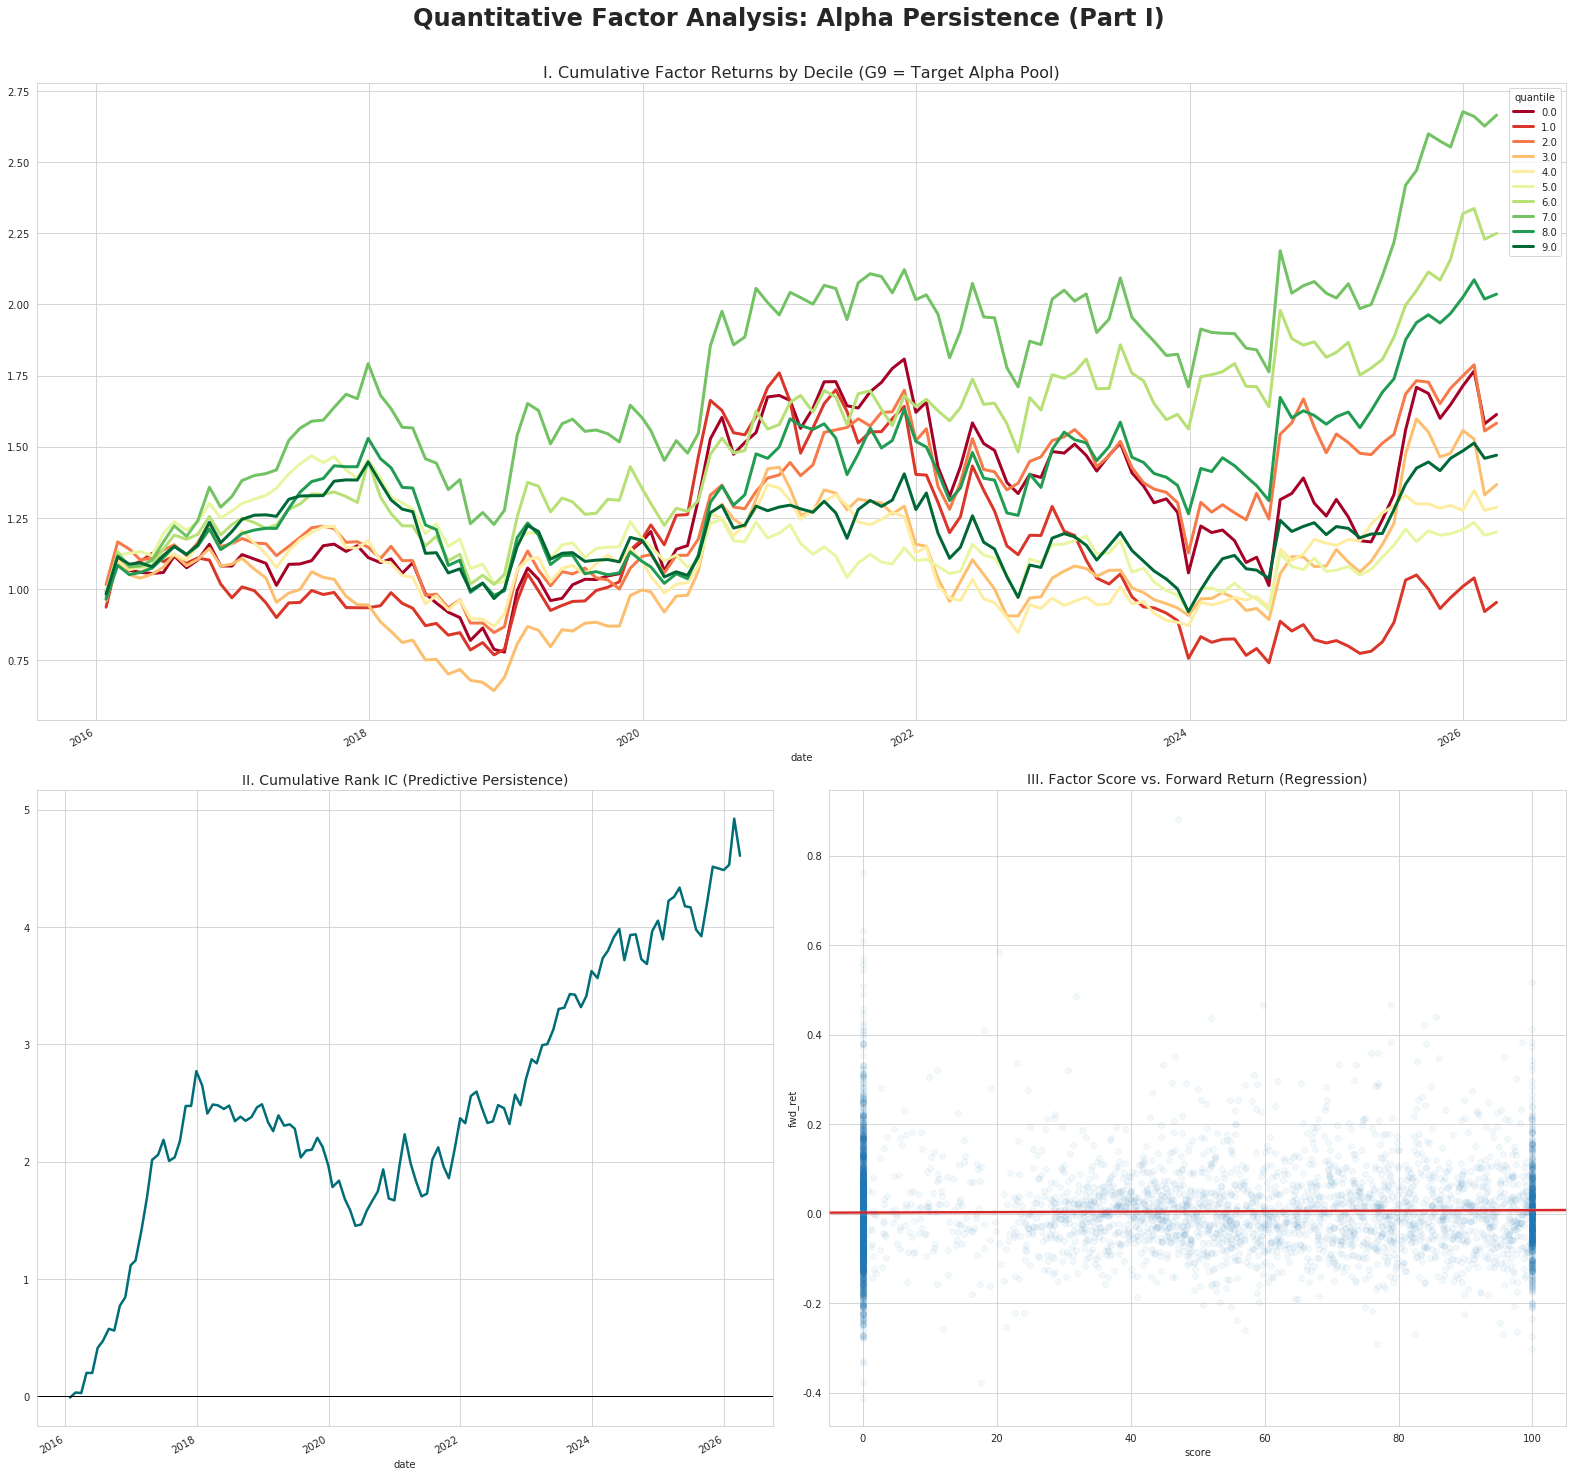

In [28]:
# ------------------------------------------------------------
# PART 5A: CORE ALPHA DIAGNOSTICS (Charts 1-4)
# ------------------------------------------------------------
fig1 = plt.figure(figsize=(22, 22))
plt.suptitle('Quantitative Factor Analysis: Alpha Persistence (Part I)', fontsize=24, fontweight='bold', y=0.96)

# I. Cumulative Wealth Index
ax1 = plt.subplot(2, 1, 1)
(1 + q_ret).cumprod().plot(ax=ax1, colormap='RdYlGn', lw=3)
ax1.set_title("I. Cumulative Factor Returns by Decile (G9 = Target Alpha Pool)", fontsize=16)

# II. Cumulative Rank IC
ax2 = plt.subplot(2, 2, 3)
ic_ts.cumsum().plot(ax=ax2, color='#006d77', lw=2.5)
ax2.axhline(0, color='black', lw=1)
ax2.set_title("II. Cumulative Rank IC (Predictive Persistence)", fontsize=14)

# III. Cross-Sectional Regression
ax3 = plt.subplot(2, 2, 4)
sample_data = master_df.sample(n=min(len(master_df), 5000))
sns.regplot(x='score', y='fwd_ret', data=sample_data, scatter_kws={'alpha':0.05}, line_kws={'color':'#d62828'}, ax=ax3)
ax3.set_title("III. Factor Score vs. Forward Return (Regression)", fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

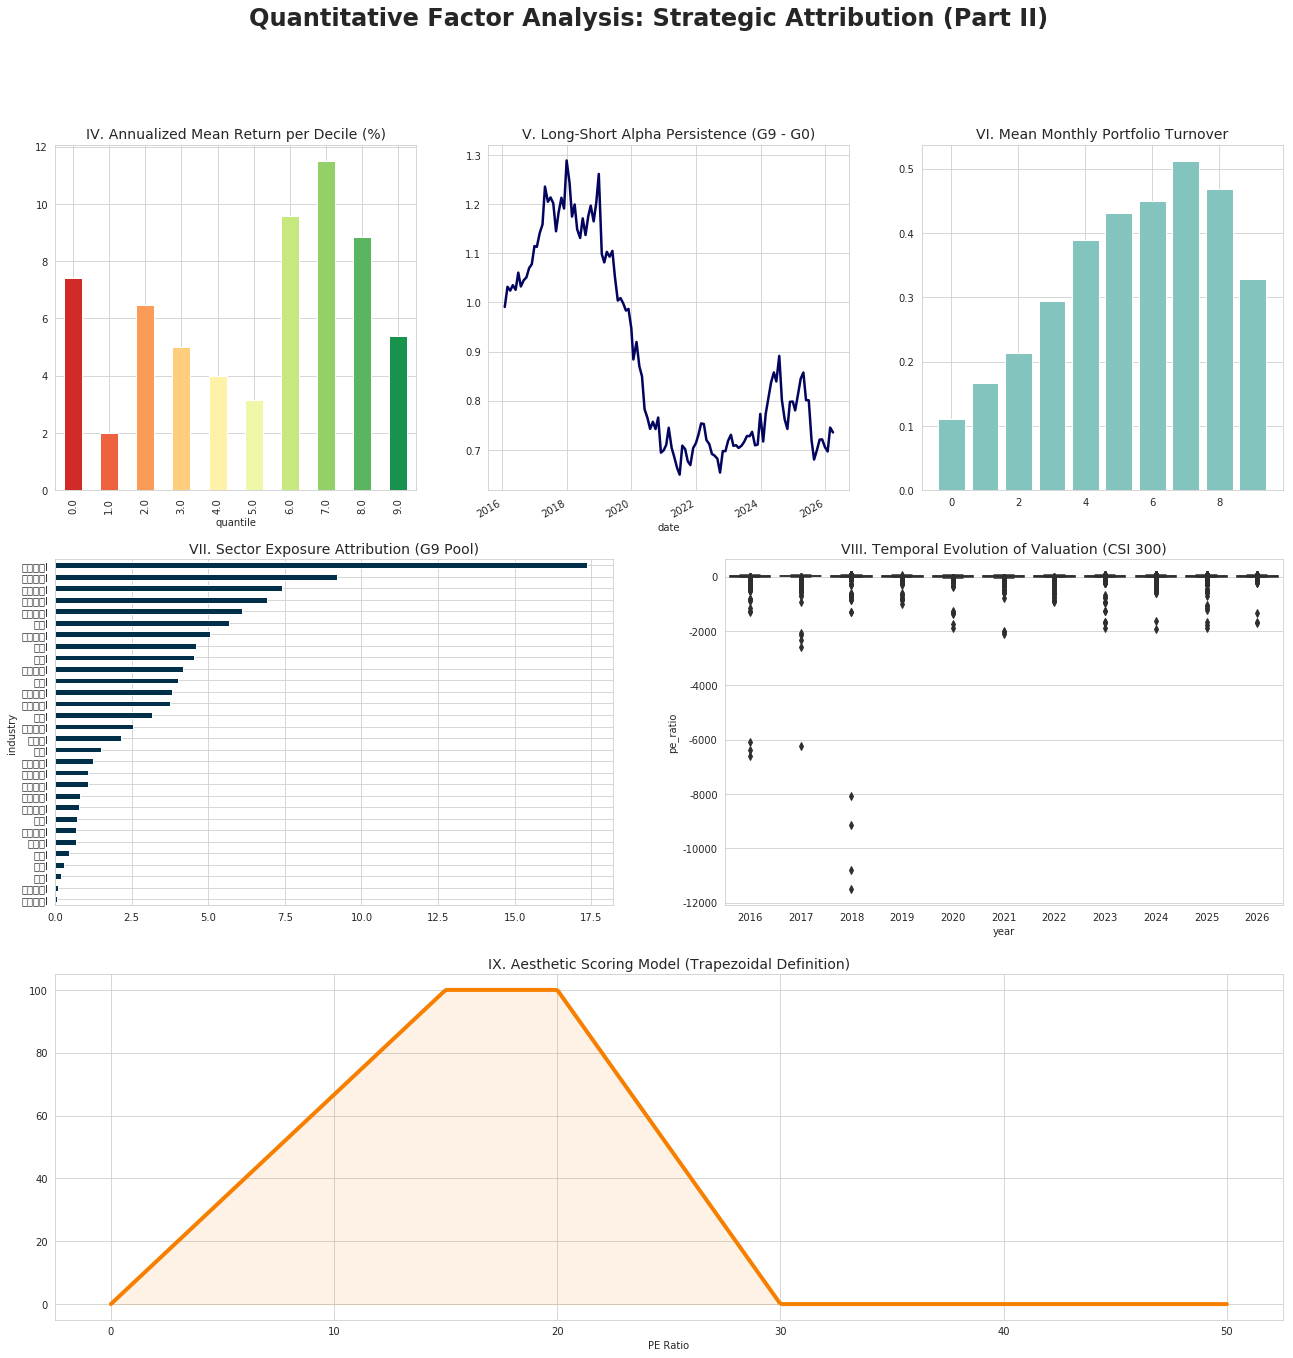


FINAL STRATEGIC SUMMARY STATISTICS
--------------------------------------------------------------------------------
Average Rank IC: 0.0375 | ICIR: 0.2420
L/S Alpha (Ann.): -2.01%


In [29]:
# ------------------------------------------------------------
# PART 5B: STRATEGIC ATTRIBUTION (Charts 5-9)
# ------------------------------------------------------------
fig2 = plt.figure(figsize=(22, 24))
plt.suptitle('Quantitative Factor Analysis: Strategic Attribution (Part II)', fontsize=24, fontweight='bold', y=0.96)

# IV. Annualized Mean Return
ax4 = plt.subplot(3, 3, 1)
(q_ret.mean() * 12 * 100).plot(kind='bar', color=sns.color_palette("RdYlGn", 10), ax=ax4)
ax4.set_title("IV. Annualized Mean Return per Decile (%)", fontsize=14)

# V. Long-Short Alpha Spread
ax5 = plt.subplot(3, 3, 2)
(1 + ls_spread).cumprod().plot(ax=ax5, color='#03045e', lw=2.5)
ax5.set_title("V. Long-Short Alpha Persistence (G9 - G0)", fontsize=14)

# VI. Mean Monthly Turnover
ax6 = plt.subplot(3, 3, 3)
to_data = [get_turnover(i) for i in range(10)]
ax6.bar(range(10), to_data, color='#83c5be')
ax6.set_title("VI. Mean Monthly Portfolio Turnover", fontsize=14)

# VII. Sector Exposure
ax7 = plt.subplot(3, 2, 3)
g9_ind = master_df[master_df['quantile'] == 9].groupby('industry').size()
(g9_ind / g9_ind.sum() * 100).sort_values().plot(kind='barh', color='#003049', ax=ax7)
ax7.set_title("VII. Sector Exposure Attribution (G9 Pool)", fontsize=14)

# VIII. Evolution of Valuation (Boxplot)
ax8 = plt.subplot(3, 2, 4)
box_df = master_df[master_df['pe_ratio'] < 60]
sns.boxplot(x='year', y='pe_ratio', data=box_df, palette='YlGnBu', ax=ax8)
ax8.set_title("VIII. Temporal Evolution of Valuation (CSI 300)", fontsize=14)

# IX. Scoring Model Visualization
ax9 = plt.subplot(3, 1, 3)
x_p = np.linspace(0, 50, 500)
y_s = [calculate_aesthetic_score(p) for p in x_p]
ax9.plot(x_p, y_s, color='#f77f00', lw=4)
ax9.fill_between(x_p, 0, y_s, alpha=0.1, color='#f77f00')
ax9.set_title("IX. Aesthetic Scoring Model (Trapezoidal Definition)", fontsize=14)
ax9.set_xlabel("PE Ratio")

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

# 最终统计打印
print("\n" + "="*80)
print("FINAL STRATEGIC SUMMARY STATISTICS")
print("-" * 80)
print("Average Rank IC: {:.4f} | ICIR: {:.4f}".format(ic_ts.mean(), ic_ts.mean()/ic_ts.std()))
print("L/S Alpha (Ann.): {:.2f}%".format(ls_spread.mean()*12*100))
print("="*80)